# Test sur 20 images 


In [1]:
# Importing the libraries
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from src.alpha_expansion.image_to_graph_BW import AlphaExpansion
from src.alpha_expansion.alpha_expansion_dinic import AlphaExpansionDinic

## Avec la libraire pymaxflow

Flot maximal : 17141584.814350374
Flot maximal : 36285036.45233049
Flot maximal : 45439090.922862306
Flot maximal : 50847472.21677491
Flot maximal : 61268824.11056644


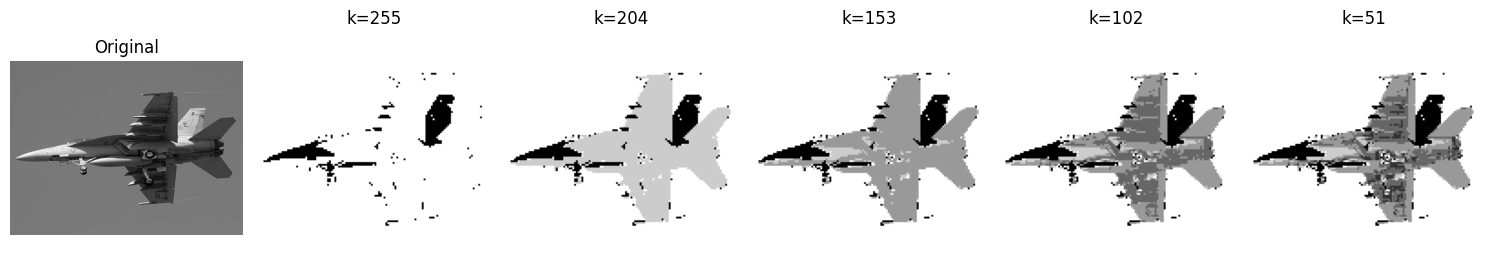

Flot maximal : 9758079.353595953
Flot maximal : 37319922.32517204
Flot maximal : 56703329.629441015
Flot maximal : 70354084.45577292
Flot maximal : 81390132.19556375


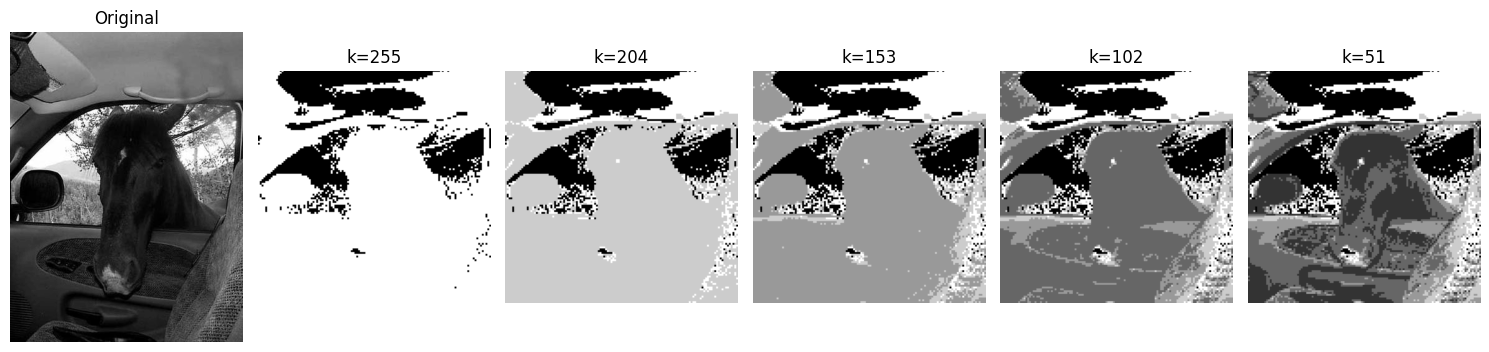

Flot maximal : 14522029.260880992
Flot maximal : 31989469.300391927
Flot maximal : 41744408.64607526
Flot maximal : 50896534.221180975
Flot maximal : 63725243.814211644


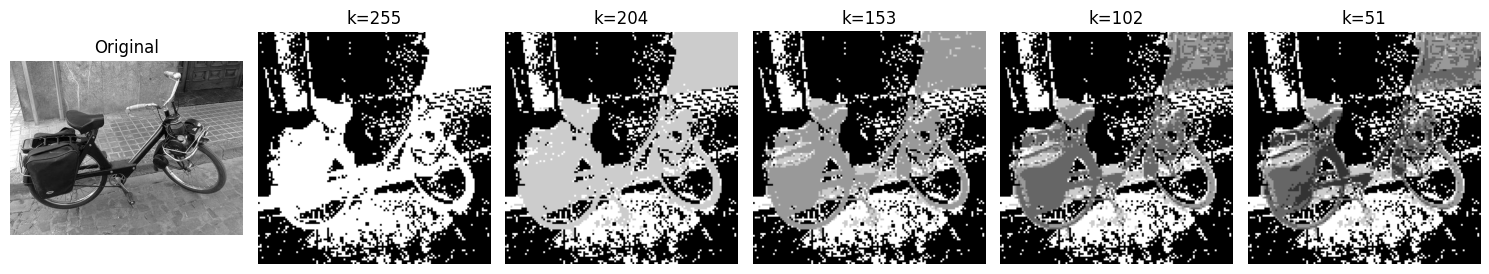

Flot maximal : 9145779.592369992
Flot maximal : 34197385.87765258
Flot maximal : 52589180.77333068
Flot maximal : 66584734.7702764
Flot maximal : 79607551.1504803


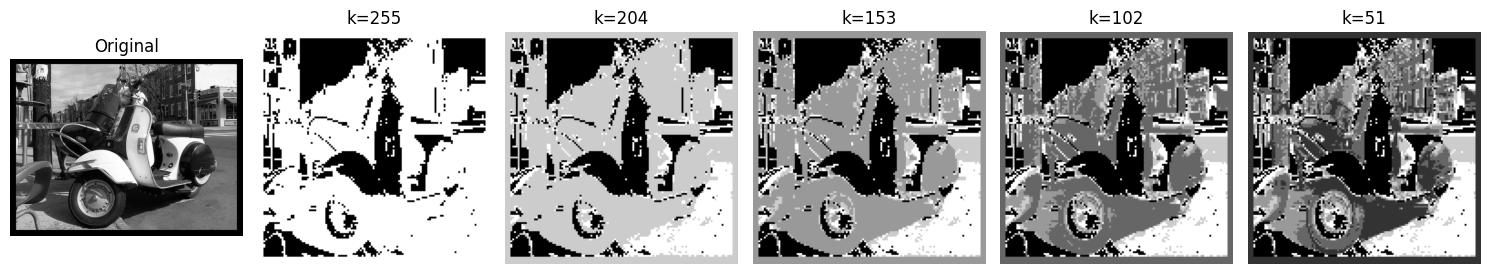

Flot maximal : 11835639.803810664
Flot maximal : 21688490.911536373
Flot maximal : 29813987.470720213
Flot maximal : 42362515.68055593
Flot maximal : 60649714.37507157


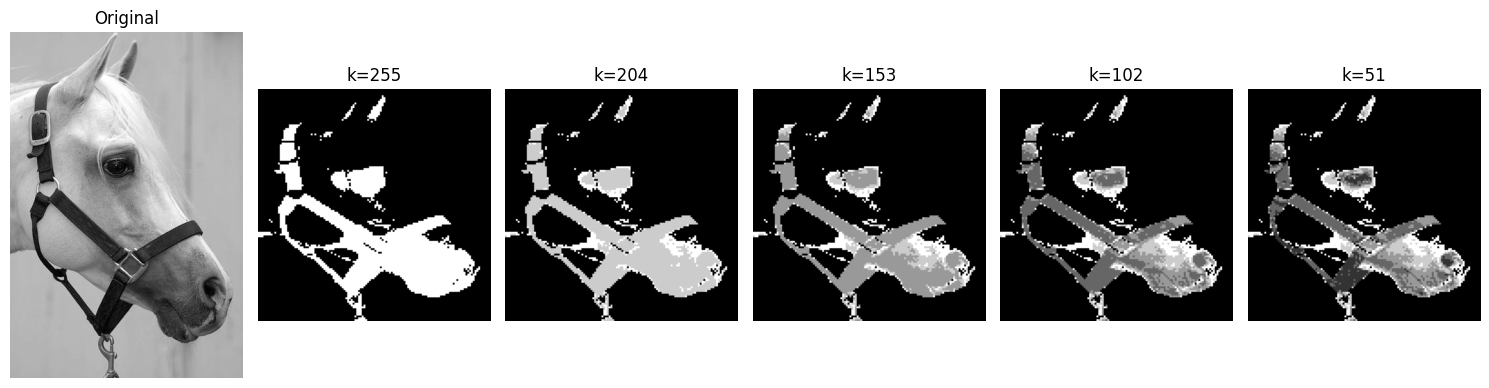

Flot maximal : 9783999.826827884
Flot maximal : 33337622.21183061
Flot maximal : 51265218.12186991
Flot maximal : 64432203.16229595
Flot maximal : 75286752.67416811


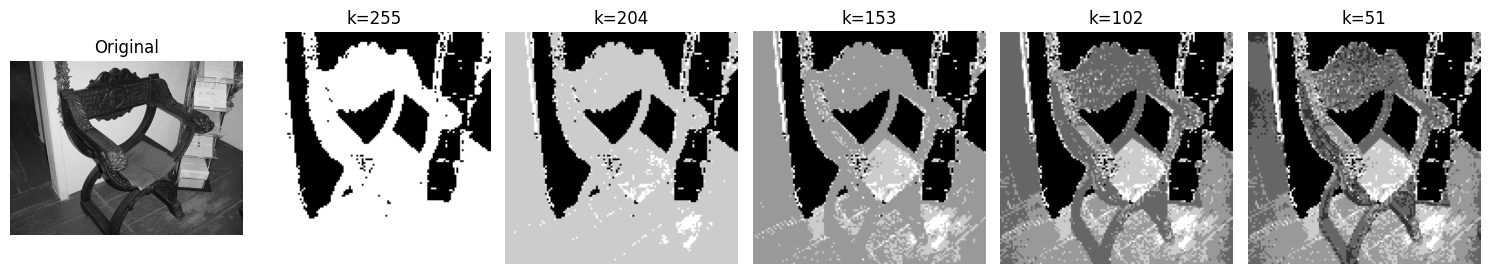

Flot maximal : 9072570.672138434
Flot maximal : 37687771.857396595
Flot maximal : 58390515.8306959
Flot maximal : 72260579.2812574
Flot maximal : 82066365.74539277


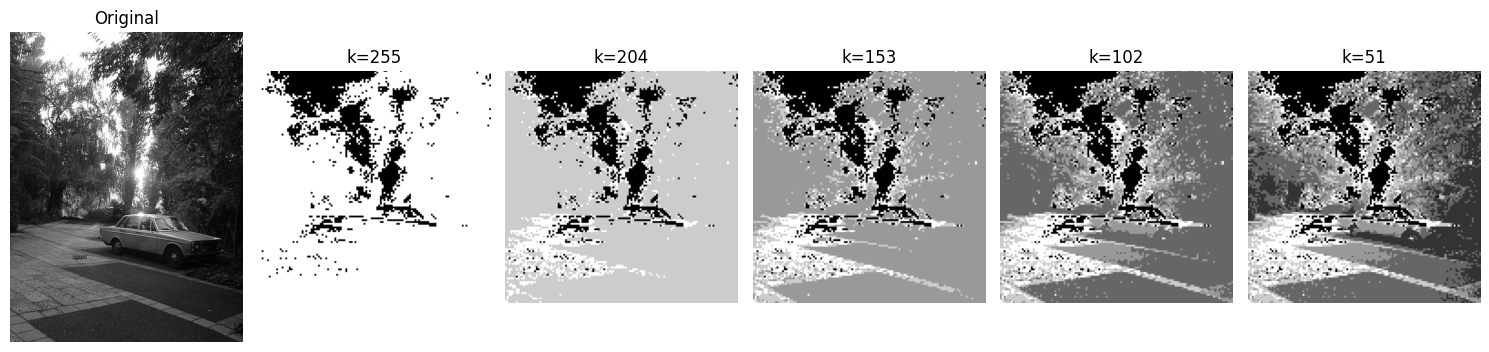

Flot maximal : 10985611.908680514
Flot maximal : 28918861.575162765
Flot maximal : 42443118.37773663
Flot maximal : 55884737.869023986
Flot maximal : 70177627.4477454


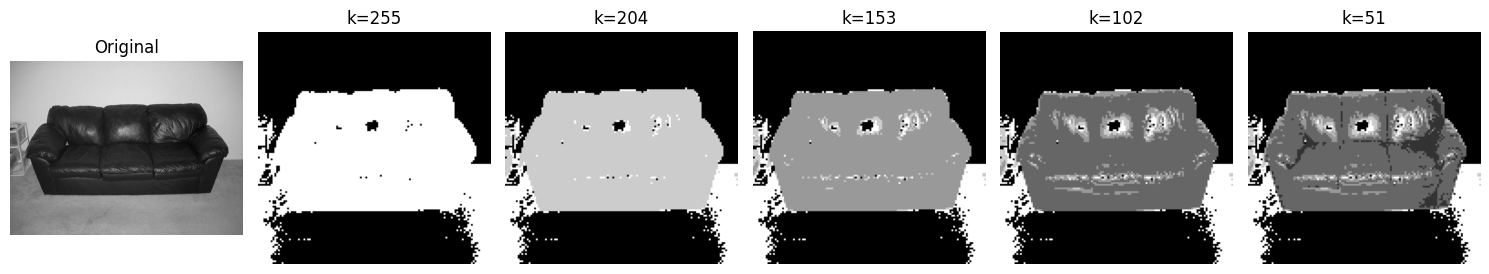

Flot maximal : 12941284.011563912
Flot maximal : 33826093.67600943
Flot maximal : 46312999.963794984
Flot maximal : 55037181.977647275
Flot maximal : 66267383.22242361


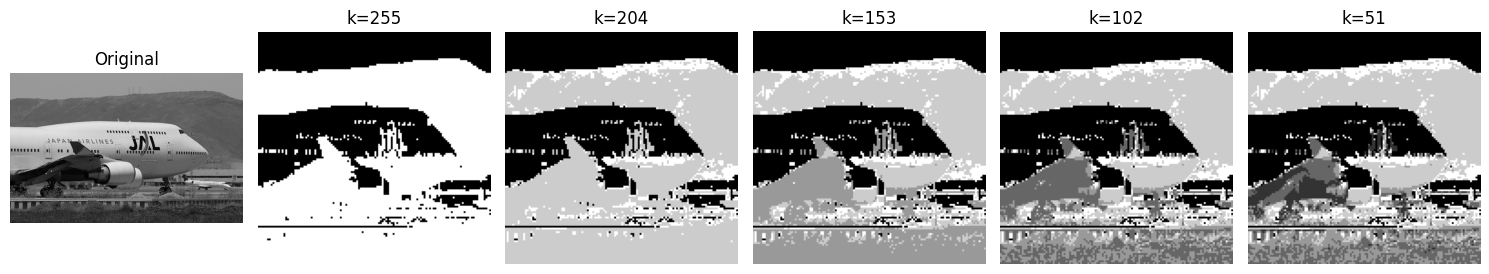

Flot maximal : 8365559.849906659
Flot maximal : 15156401.252521906
Flot maximal : 25033102.138737585
Flot maximal : 41246568.69934632
Flot maximal : 65667610.0


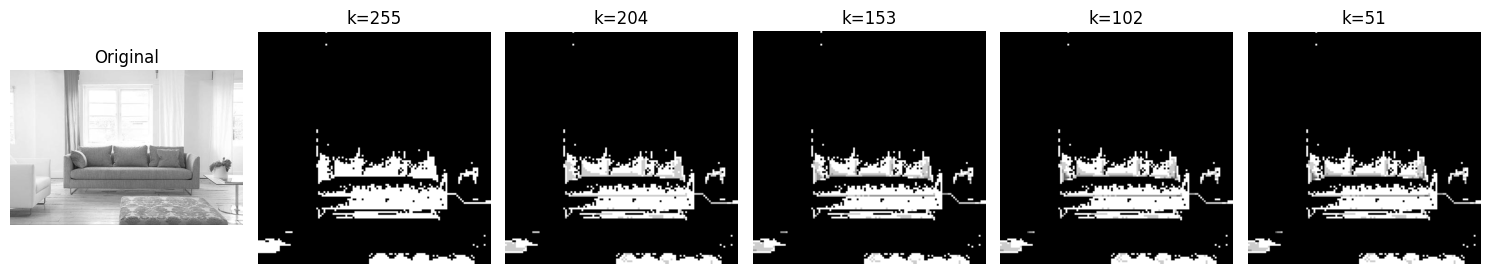

Flot maximal : 14068076.129130576
Flot maximal : 31456227.443851817
Flot maximal : 41348457.821919434
Flot maximal : 50121770.27039956
Flot maximal : 62400589.596396804


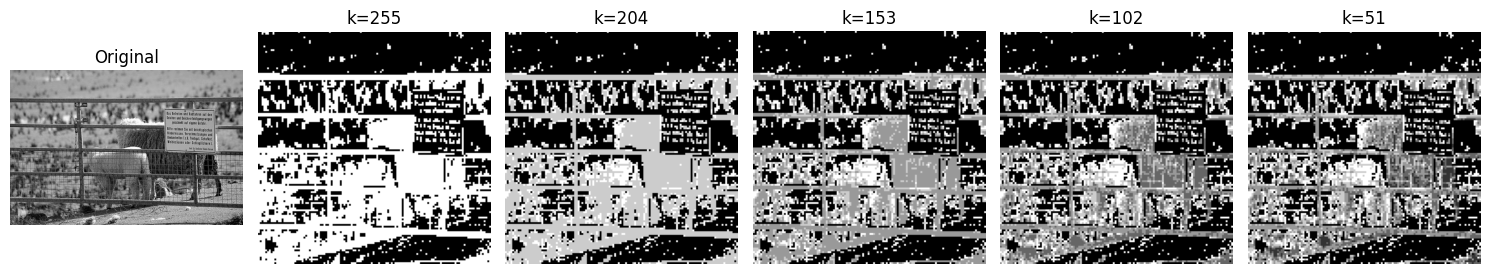

Flot maximal : 12336505.05980616
Flot maximal : 35543698.96605539
Flot maximal : 50267800.986088805
Flot maximal : 59850444.23905284
Flot maximal : 71023281.40717681


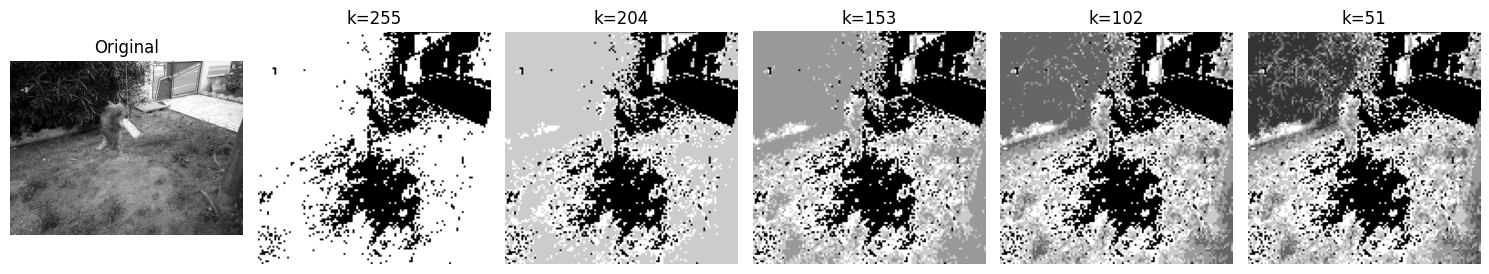

Flot maximal : 12404310.653991438
Flot maximal : 32435264.8776185
Flot maximal : 45514673.67726595
Flot maximal : 55585681.88838757
Flot maximal : 68277997.54723619


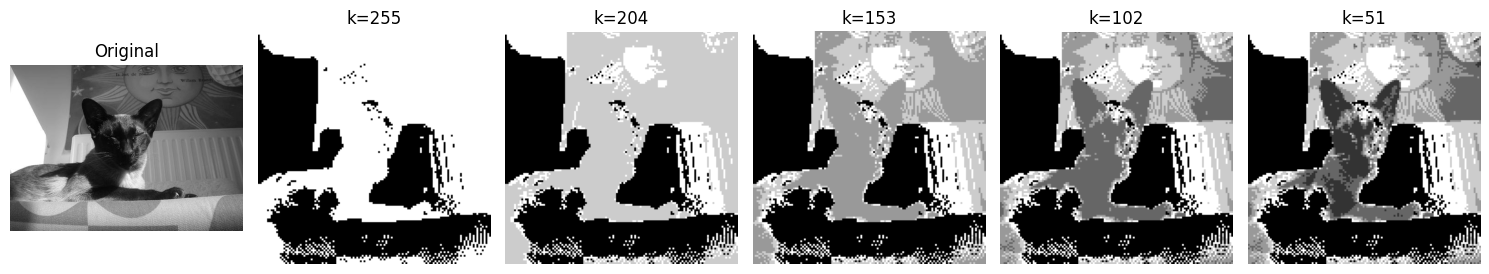

Flot maximal : 7205913.705847202
Flot maximal : 21454908.007456567
Flot maximal : 36168532.19087819
Flot maximal : 52831129.09697745
Flot maximal : 73301845.84452324


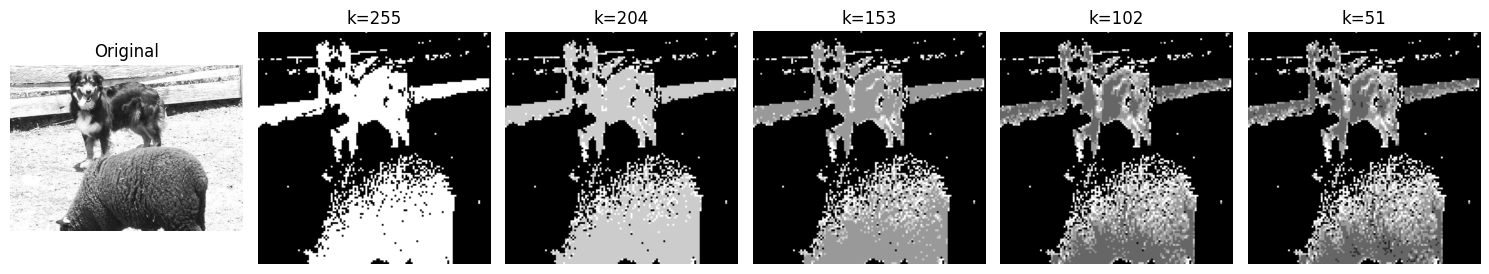

Flot maximal : 9957180.644936256
Flot maximal : 34510525.35062275
Flot maximal : 52287436.04795978
Flot maximal : 65695600.924138285
Flot maximal : 77125755.12989837


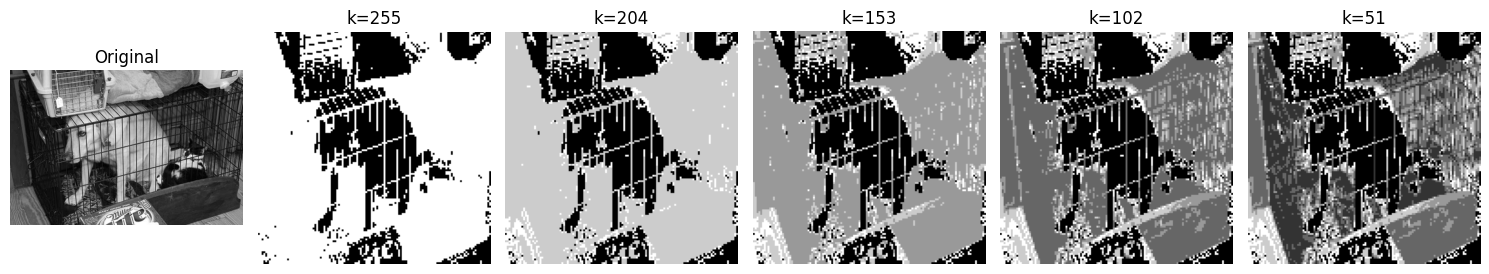

Flot maximal : 12564273.274027776
Flot maximal : 27935956.360876504
Flot maximal : 38452306.082343556
Flot maximal : 48478814.584150404
Flot maximal : 63555300.81459574


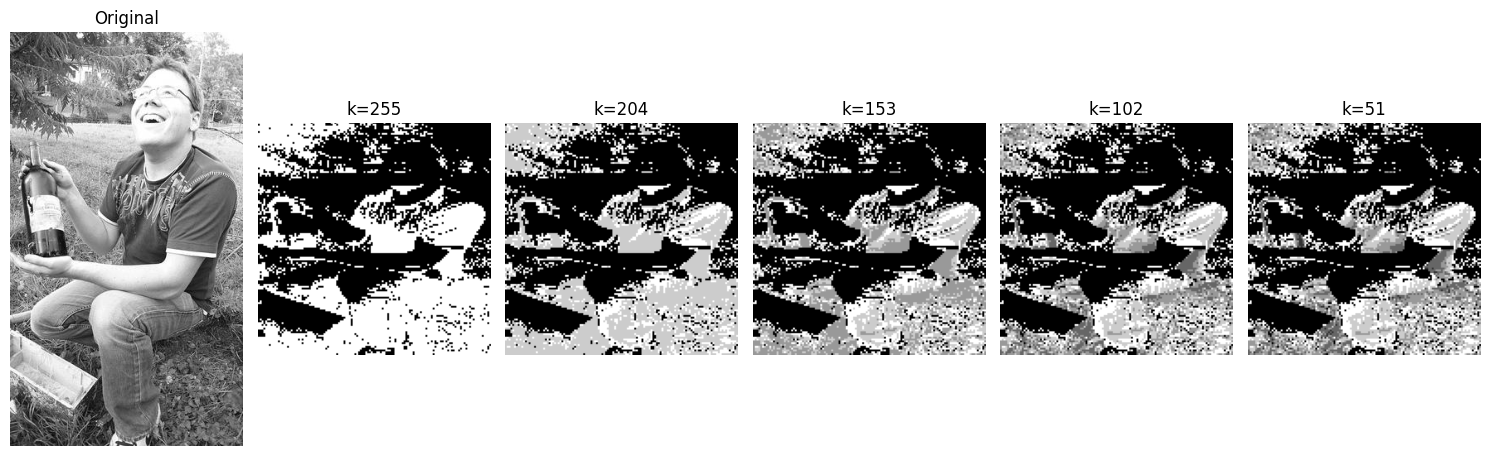

Flot maximal : 10359520.856309082
Flot maximal : 33588096.00589587
Flot maximal : 50516568.47479401
Flot maximal : 63443929.70710891
Flot maximal : 74367172.5197747


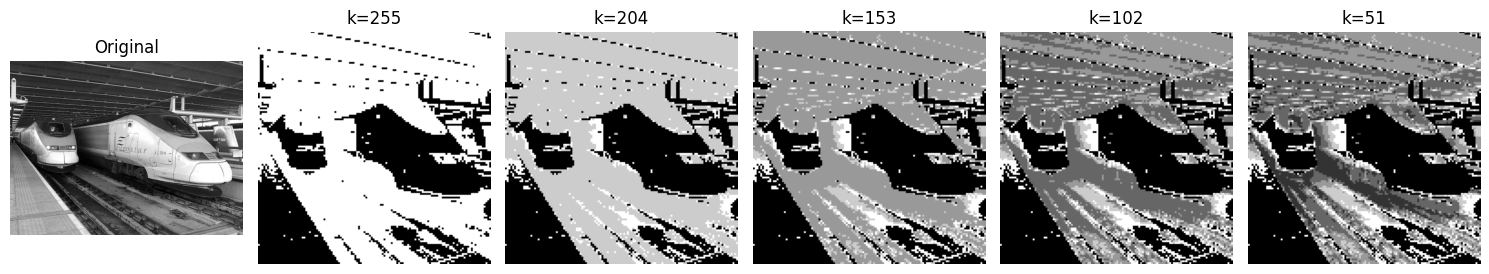

Flot maximal : 8997576.380042985
Flot maximal : 34812257.58003926
Flot maximal : 54023542.60488289
Flot maximal : 68212783.99726623
Flot maximal : 80142463.27929305


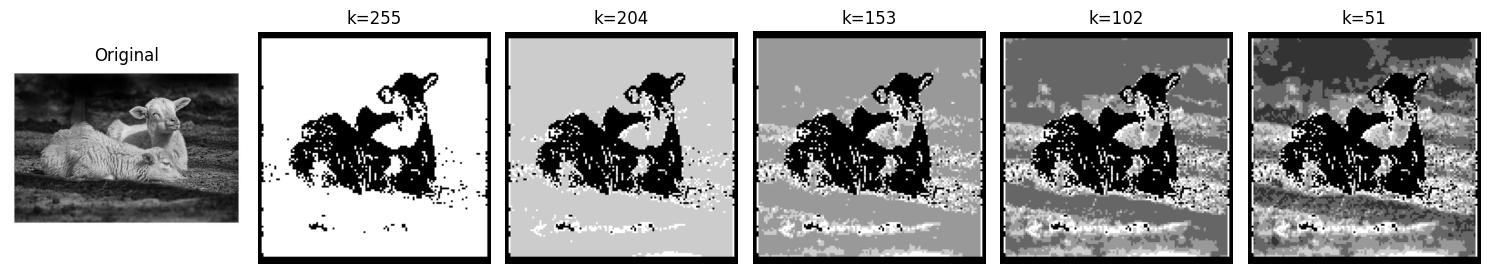

Flot maximal : 14485118.312539913
Flot maximal : 31294773.917369027
Flot maximal : 40762527.657449745
Flot maximal : 48602817.499623075
Flot maximal : 61209564.75746967


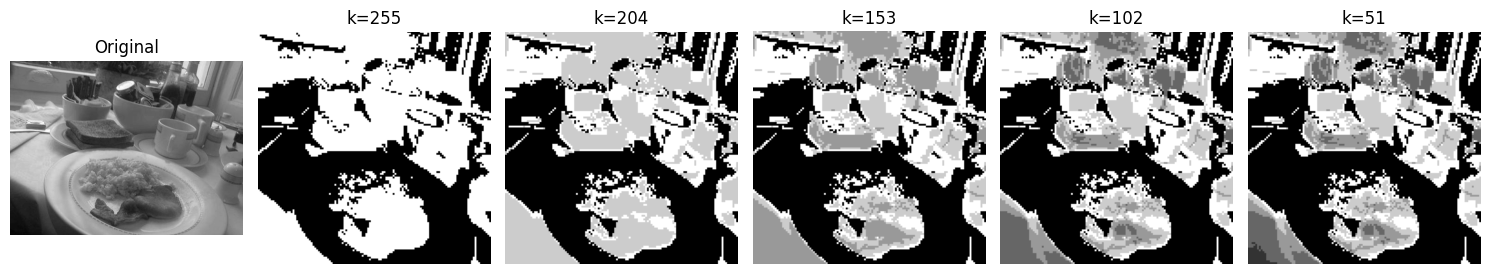

Flot maximal : 10749839.500055052
Flot maximal : 33644926.514988
Flot maximal : 49931917.05645125
Flot maximal : 61371085.45575481
Flot maximal : 73295606.47277452


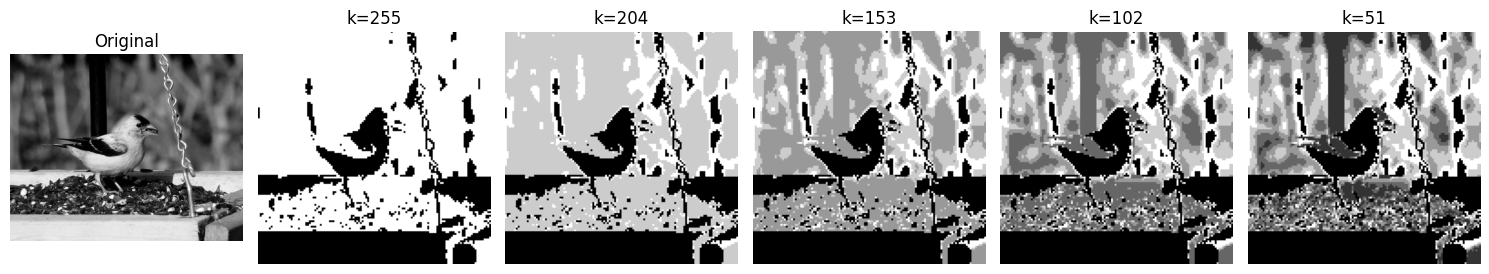

In [2]:
def process_images(k, folder_path):
    """
    Applique un traitement sur chaque image du dossier en fonction des valeurs de k.
    
    :param k_values: Liste des valeurs de k.
    :param folder_path: Chemin du dossier contenant les images.
    """
    # Générer k valeurs uniformément réparties entre 0 et 255
    k_values = np.linspace(0, 255, num=k+1, dtype=int)[1:][::-1]


    # Vérifier si le dossier existe
    if not os.path.isdir(folder_path):
        raise ValueError(f"Le dossier spécifié '{folder_path}' n'existe pas.")
    
    # Récupérer la liste des fichiers image
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    
    for image_file in image_files:
        
        image_path = os.path.join(folder_path, image_file)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        # Initialisation de l'objet avec des poids personnalisés pour la source et le puit
        igc = AlphaExpansion(image_path, source_weight=10, sink_weight=10,sigma=15, source_label=255)
        # Construction du graphe (arêtes entre pixels)
        graph, nodes = igc.build_graph()
        fig, axes = plt.subplots(1, k+1, figsize=(15, 5))  # +1 pour l'image originale
        axes[0].imshow(image, cmap='gray')
        axes[0].set_title("Original")
        axes[0].axis('off')


        for i, k_val in enumerate(k_values):
            igc.source_label = k_val
            # Ajout des liens terminaux (source/puit)
            graph, nodes = igc.add_terminal_nodes()

            flow = igc.max_flow()

            segmentation = igc.segment_nodes()
            axes[i+1].imshow(segmentation, cmap='gray')
            axes[i+1].set_title(f"k={k_val}")
            axes[i+1].axis('off')
        plt.tight_layout()
        plt.show()
        plt.close()
    
# Exemple d'utilisation
folder_path = "./data"
process_images(k = 5, folder_path=folder_path)


## Avec notre max_flow Dicnic

Flot maximal : 4286273255
Flot maximal : 2045047218
Flot maximal : 1316834573


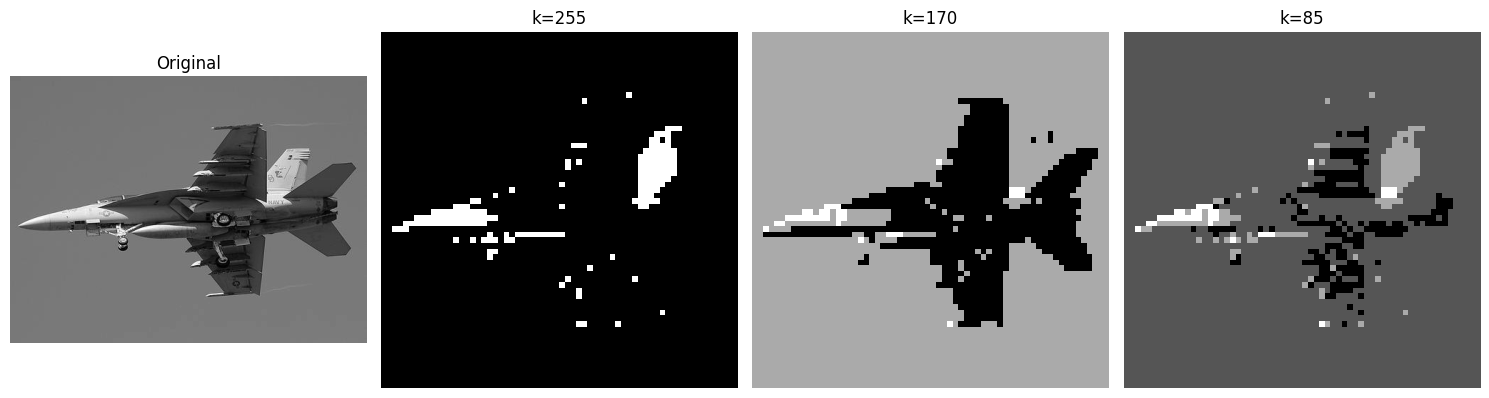

Flot maximal : 2457703730
Flot maximal : 1566422514
Flot maximal : 967963285


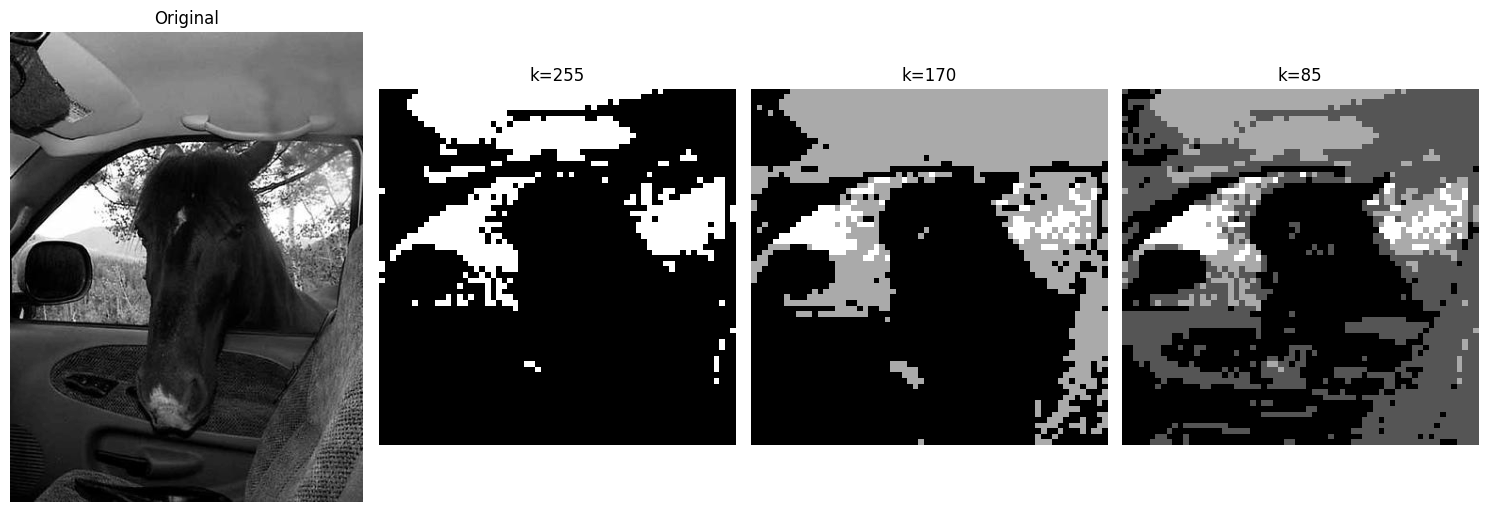

Flot maximal : 3616748047
Flot maximal : 1477042866
Flot maximal : 1006074270


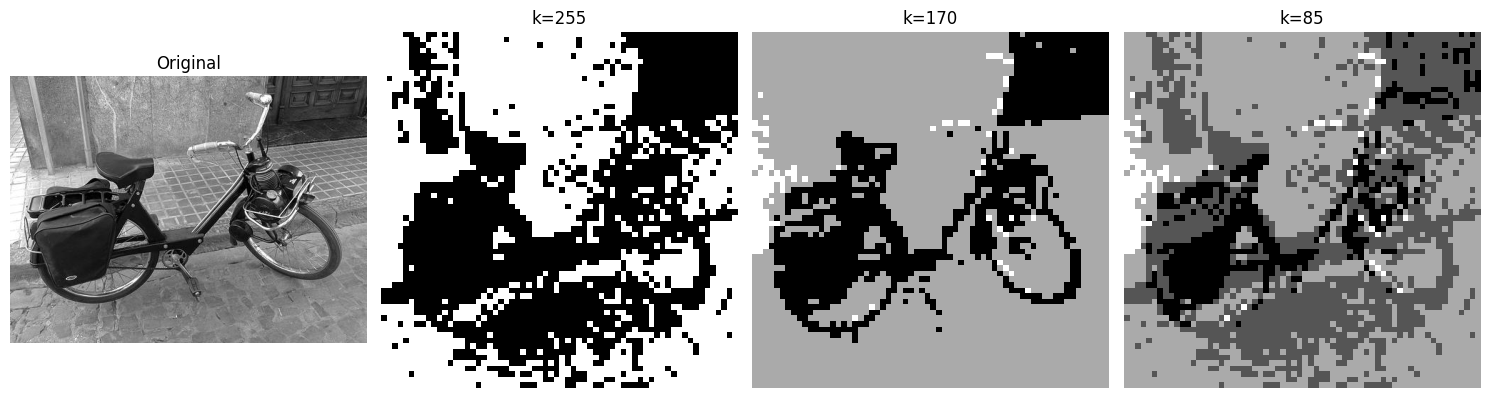

Flot maximal : 2219392200
Flot maximal : 1402762974
Flot maximal : 793296796


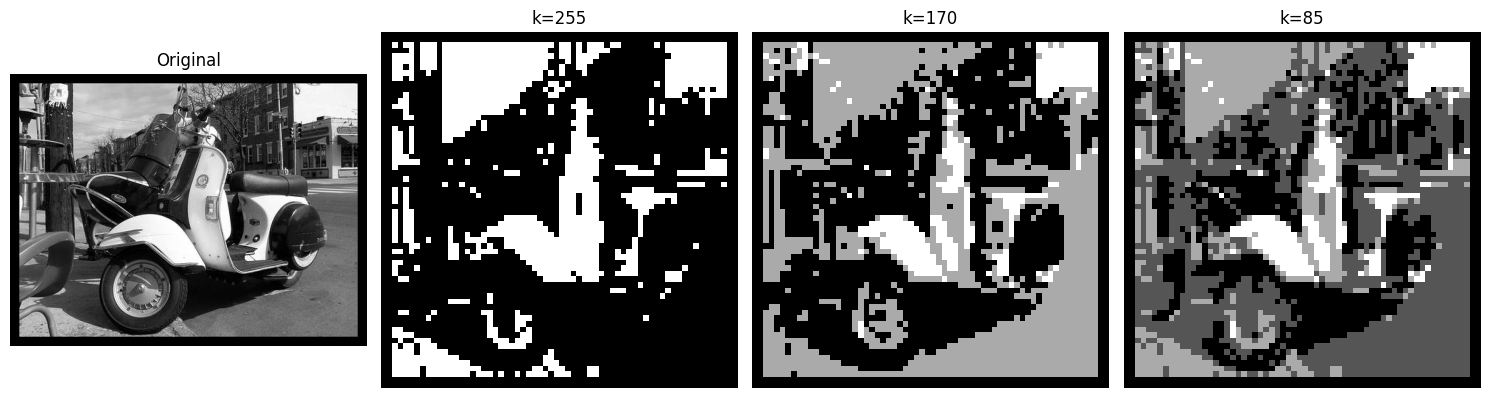

Flot maximal : 2958602640
Flot maximal : 926180067
Flot maximal : 686515970


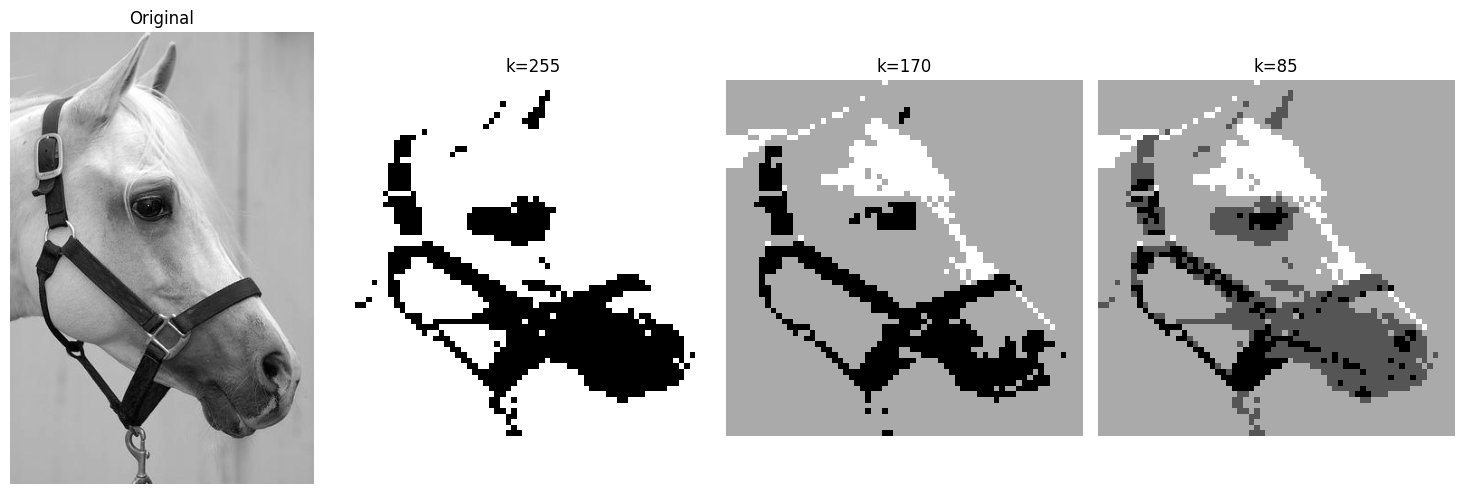

Flot maximal : 2450990772
Flot maximal : 1827220282
Flot maximal : 1014193183


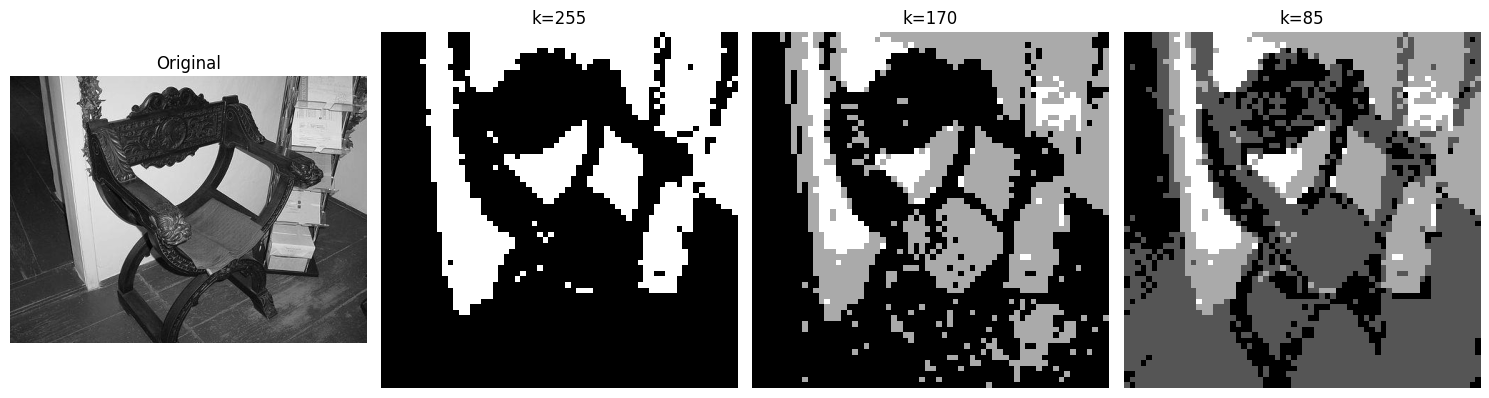

Flot maximal : 2276286451
Flot maximal : 1755422394
Flot maximal : 958971917


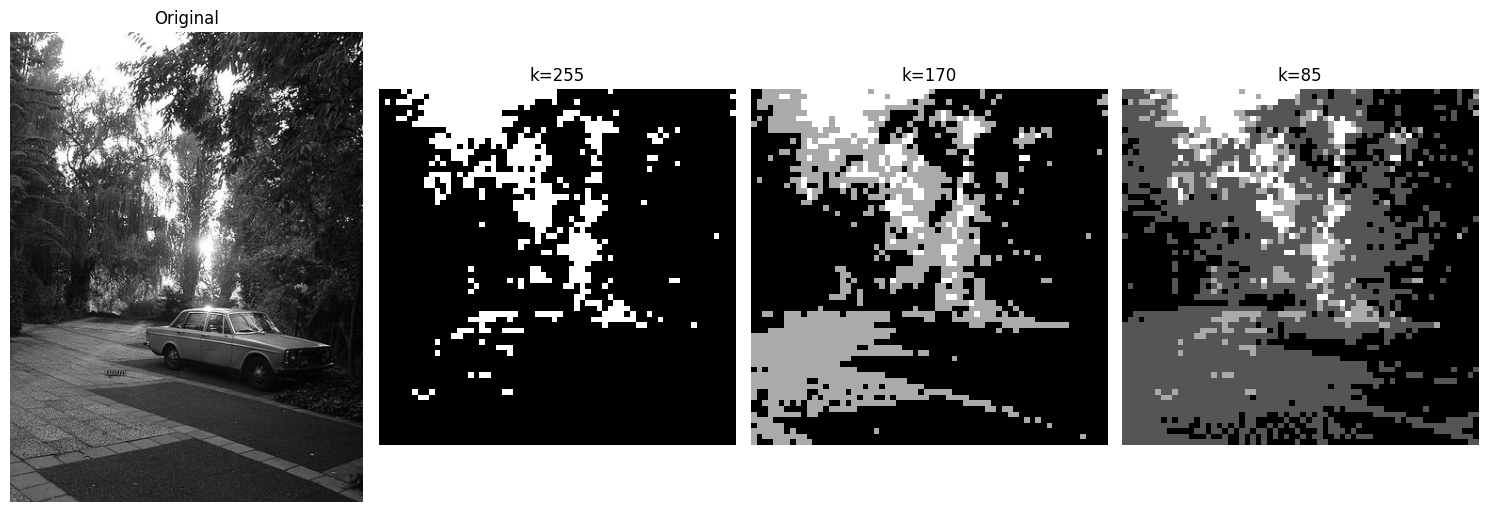

Flot maximal : 2752843572
Flot maximal : 1405151463
Flot maximal : 1168673854


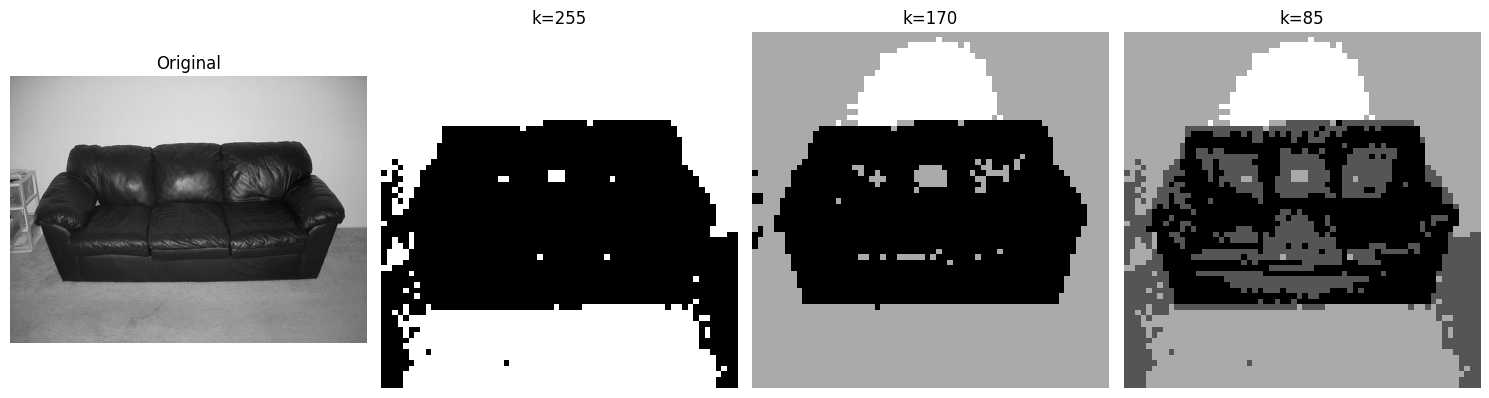

Flot maximal : 3252058407
Flot maximal : 1944309763
Flot maximal : 812047436


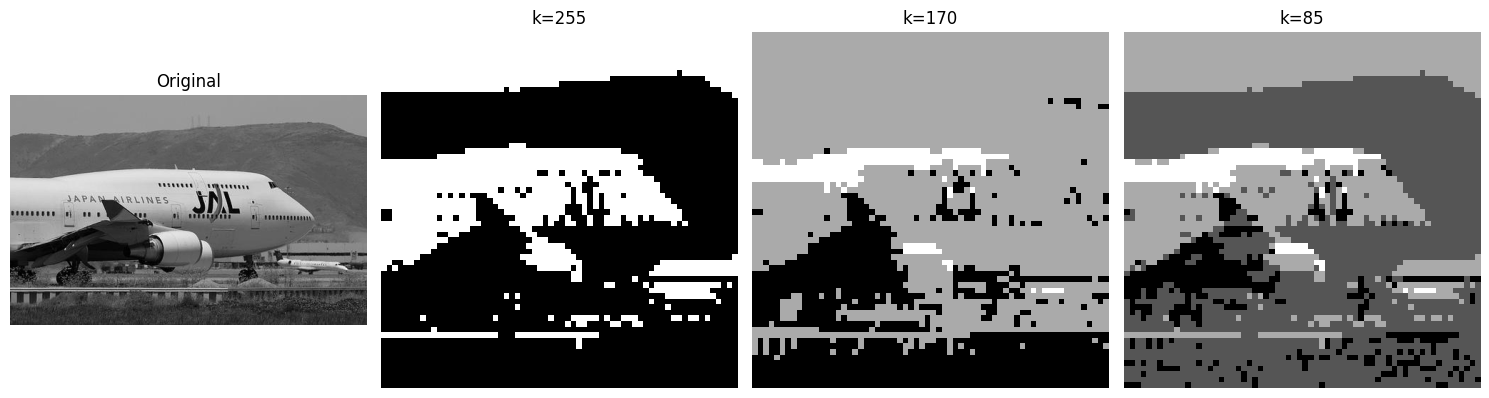

Flot maximal : 2110078394
Flot maximal : 1042379106
Flot maximal : 908028548


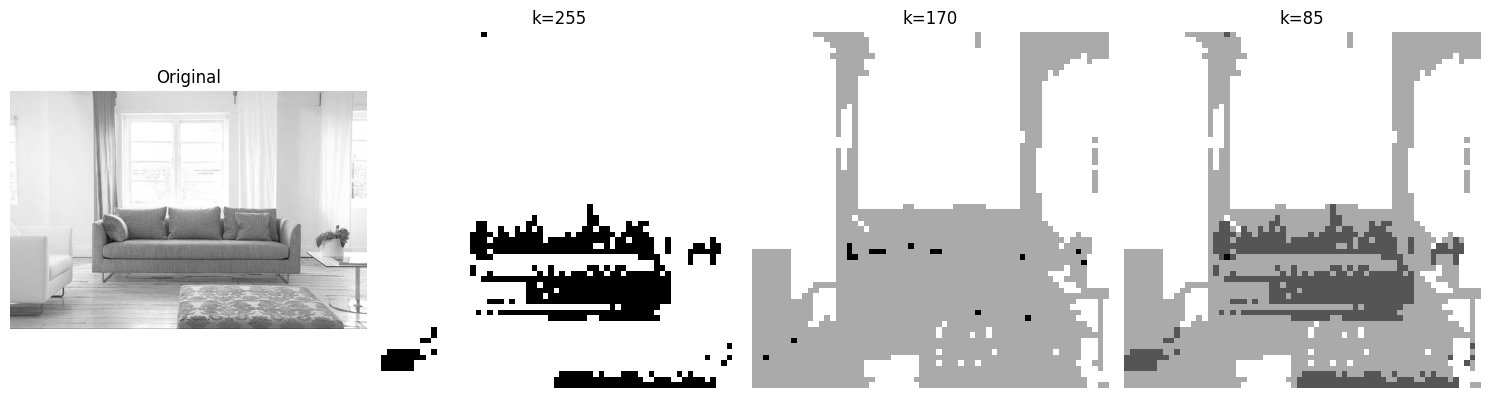

Flot maximal : 3513255357
Flot maximal : 1531441095
Flot maximal : 740654372


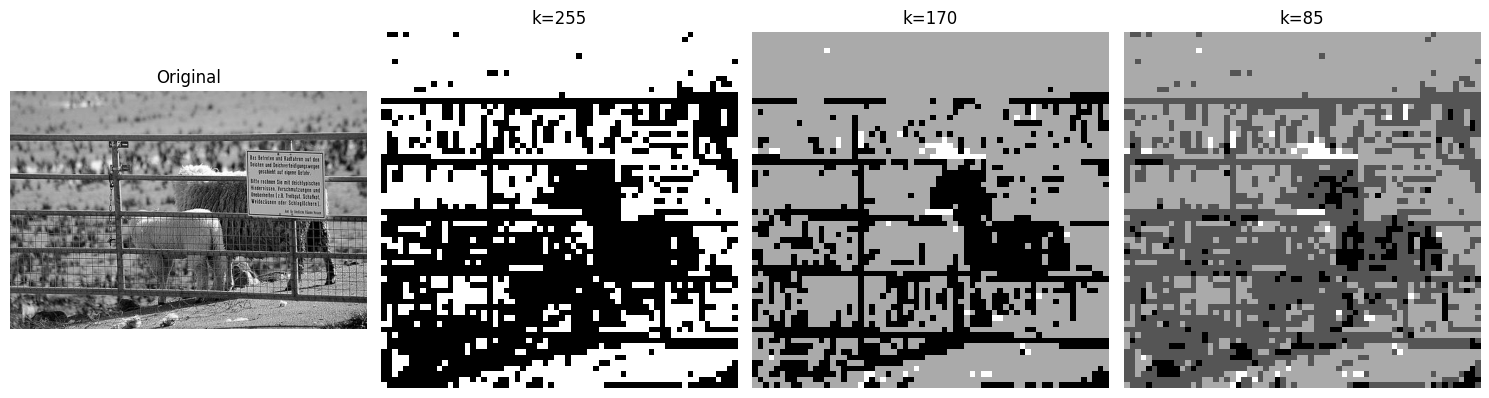

Flot maximal : 3084051193
Flot maximal : 1891399787
Flot maximal : 828915248


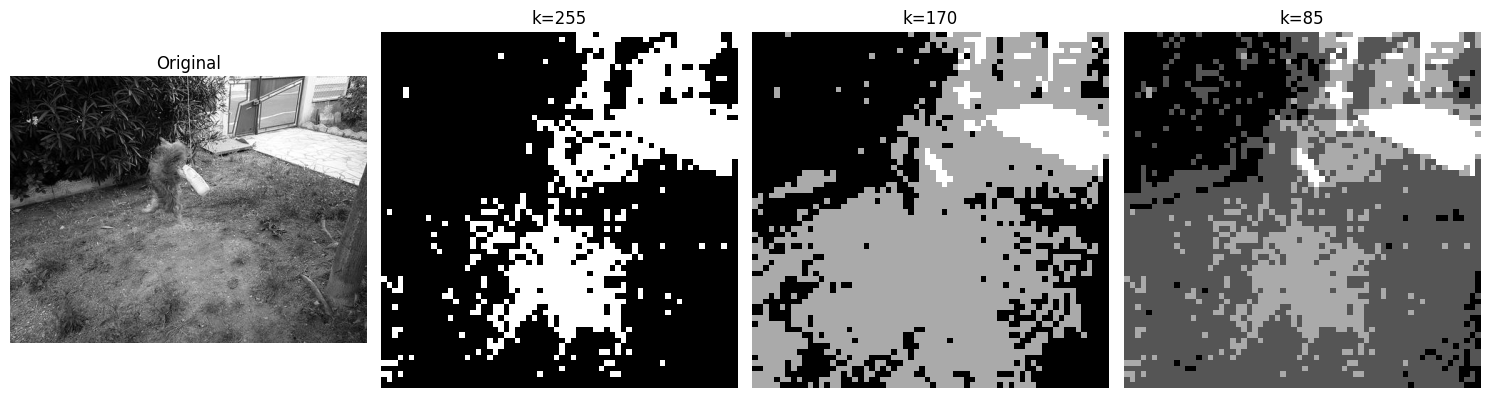

Flot maximal : 3095186102
Flot maximal : 1726459459
Flot maximal : 852453303


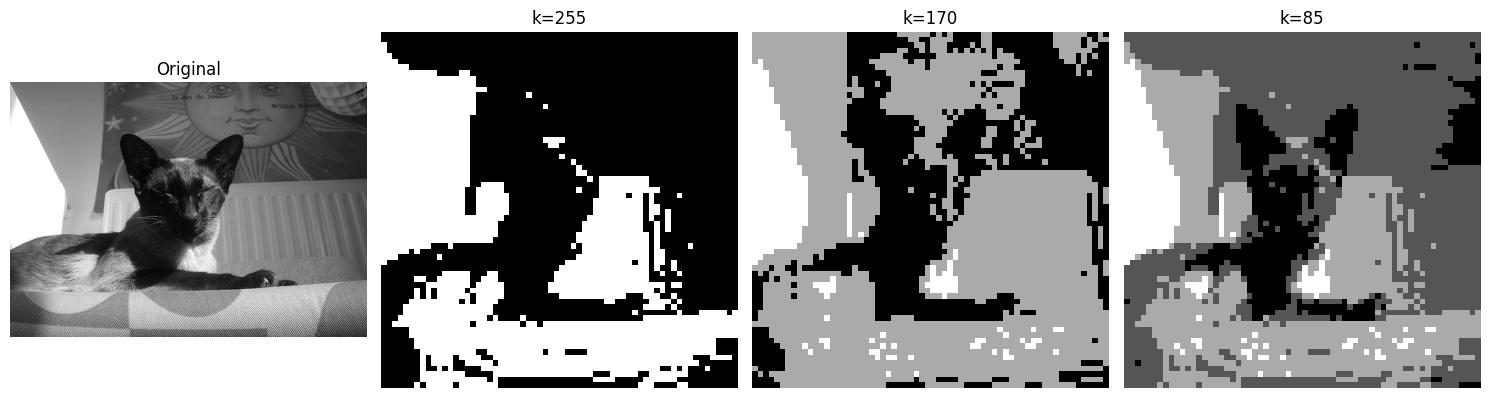

Flot maximal : 1820257940
Flot maximal : 1212588295
Flot maximal : 769907433


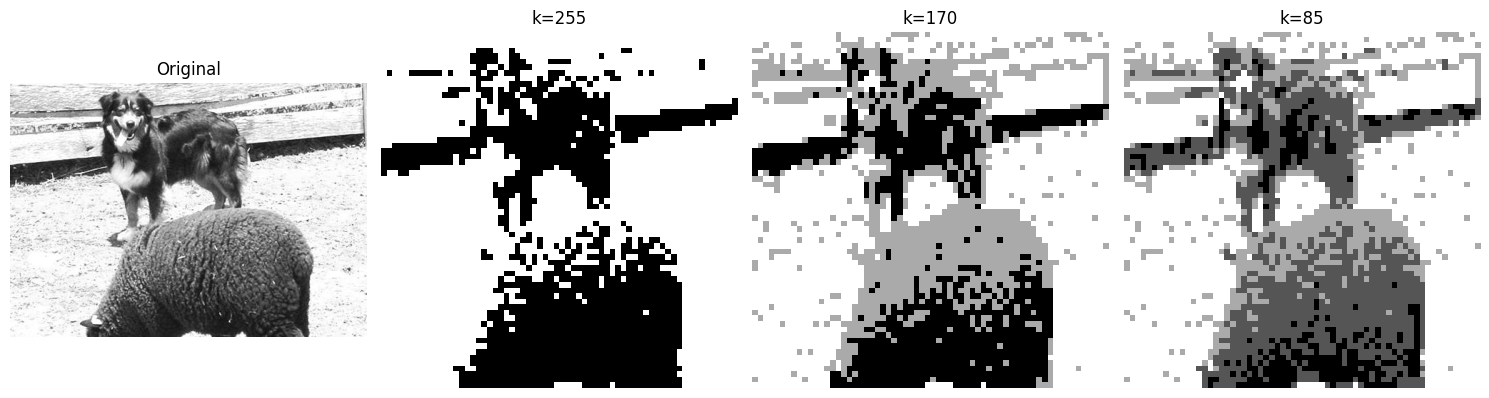

Flot maximal : 2523698374
Flot maximal : 1580539408
Flot maximal : 949138298


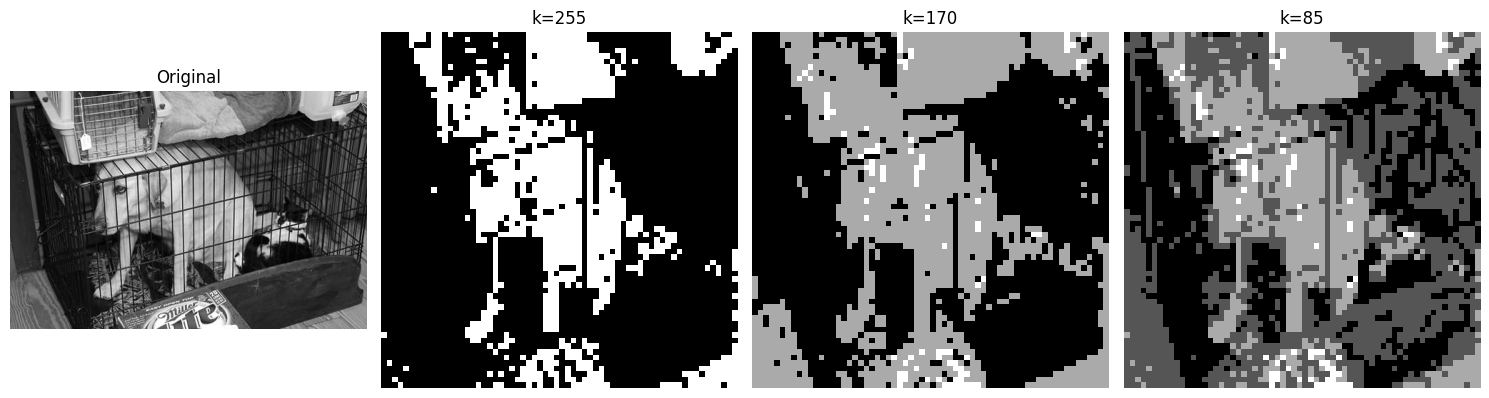

Flot maximal : 3134974823
Flot maximal : 1681243696
Flot maximal : 860937568


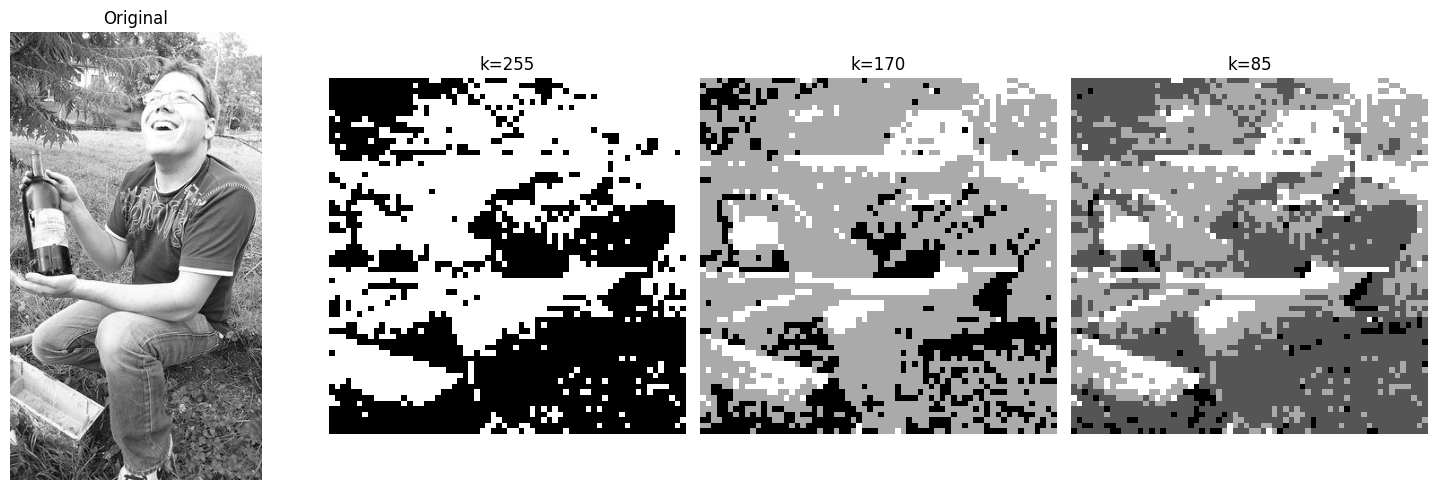

Flot maximal : 2595903132
Flot maximal : 1645669303
Flot maximal : 950876674


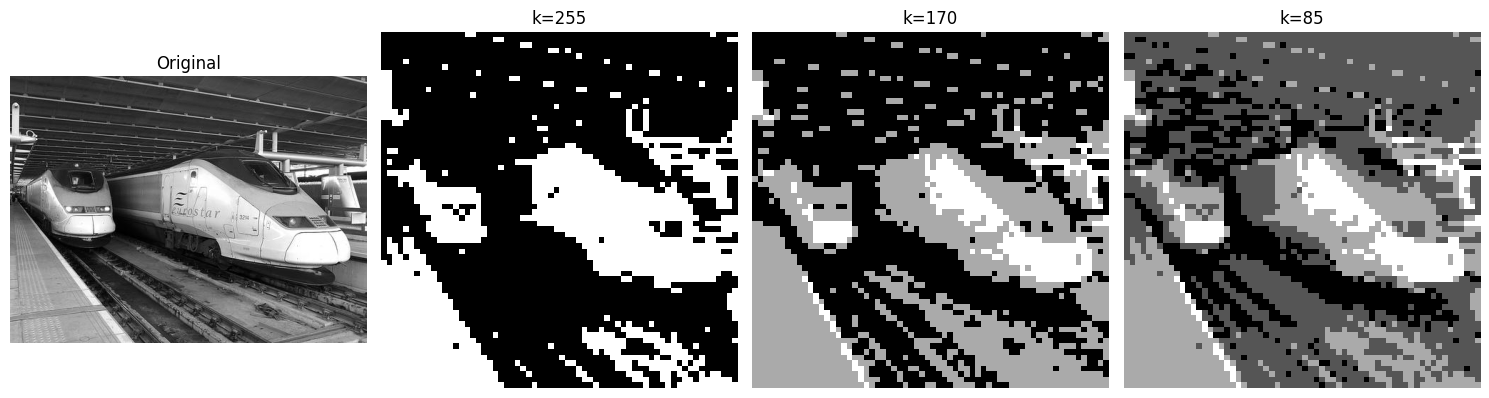

Flot maximal : 2171878161
Flot maximal : 1524048125
Flot maximal : 821879366


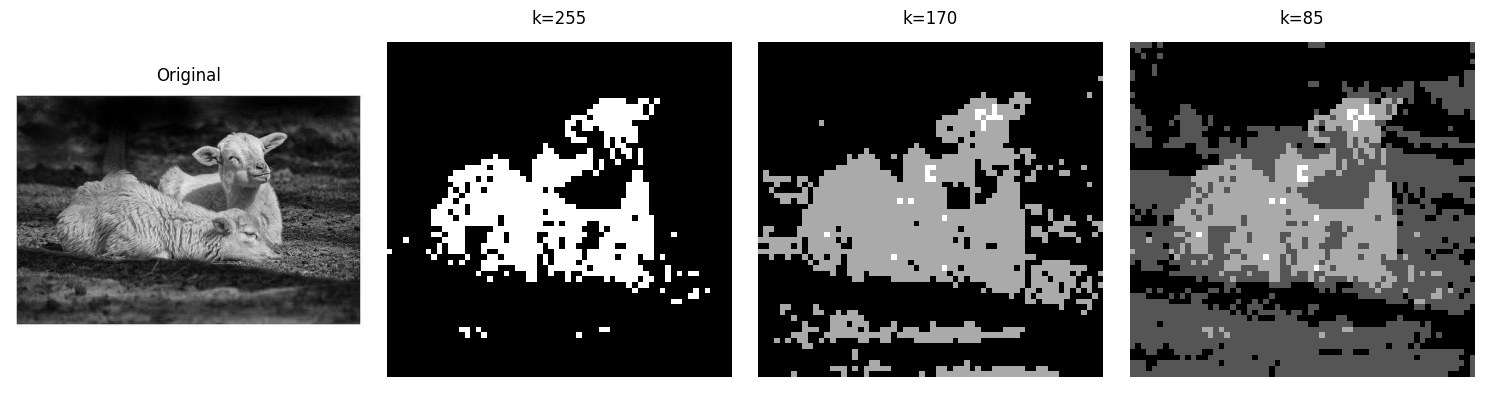

Flot maximal : 3620973423
Flot maximal : 1791548404
Flot maximal : 917011871


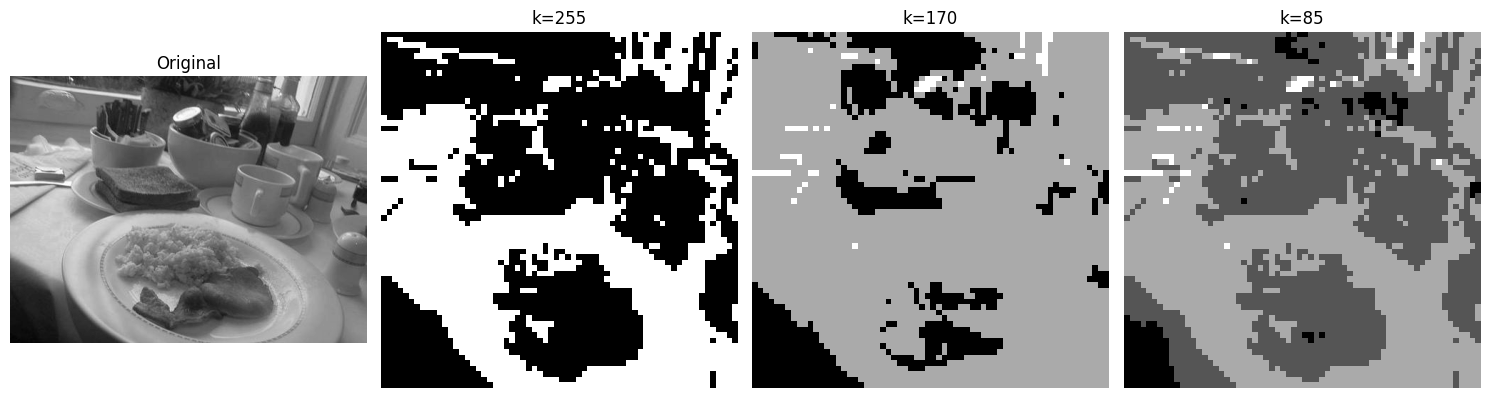

Flot maximal : 2675597596
Flot maximal : 1874251252
Flot maximal : 873128689


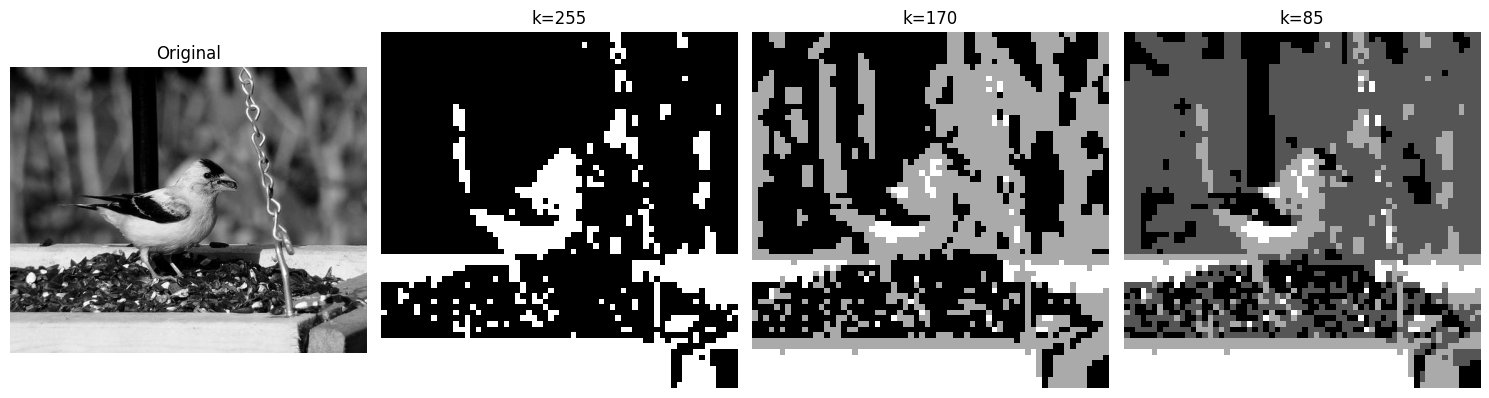

In [3]:
def process_images(k, folder_path):
    """
    Applique un traitement sur chaque image du dossier en fonction des valeurs de k.
    
    :param k_values: Liste des valeurs de k.
    :param folder_path: Chemin du dossier contenant les images.
    """
    # Générer k valeurs uniformément réparties entre 0 et 255
    k_values = np.linspace(0, 255, num=k+1, dtype=int)[1:][::-1]


    # Vérifier si le dossier existe
    if not os.path.isdir(folder_path):
        raise ValueError(f"Le dossier spécifié '{folder_path}' n'existe pas.")
    
    # Récupérer la liste des fichiers image
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    
    for image_file in image_files:
        
        image_path = os.path.join(folder_path, image_file)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        # Initialisation de l'objet avec des poids personnalisés pour la source et le puit
        igc = AlphaExpansionDinic(image_path, source_weight=10, sink_weight=10,sigma=15, source_label=255)
        # Construction du graphe (arêtes entre pixels)
        fig, axes = plt.subplots(1, k+1, figsize=(15, 5))  # +1 pour l'image originale
        axes[0].imshow(image, cmap='gray')
        axes[0].set_title("Original")
        axes[0].axis('off')


        for i, k_val in enumerate(k_values):
            igc.source_label = k_val
            igc.compute_max_flow()
            # Ajout des liens terminaux (source/puit)
            segmentation = igc.segment_nodes()
            axes[i+1].imshow(segmentation, cmap='gray')
            axes[i+1].set_title(f"k={k_val}")
            axes[i+1].axis('off')
        plt.tight_layout()
        plt.show()
        plt.close()

# Exemple d'utilisation
folder_path = "./data"
process_images(k = 3, folder_path=folder_path)
